### Google Colab에 Java 환경 세팅

In [ ]:
# Java 설치
!apt-get update -q
!apt-get install -y openjdk-17-jdk-headless

# 환경 변수 설정
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-17-openjdk-amd64'
os.environ['PATH'] += ':/usr/lib/jvm/java-17-openjdk-amd64/bin'

### 문장 토큰 수 확인

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/371k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

[문장 35145] 아이스아메리카노 하나요
  → 토큰: ['▁아이', '스', '아', '메', '리', '카', '노', '▁하나', '요']
[문장 35147] 네 텀블러에 넣어주세요
  → 토큰: ['▁네', '▁', '텀', '블', '러', '에', '▁넣어', '주세요']
[문장 35148] 그란데 사이즈로 주세요
  → 토큰: ['▁그', '란', '데', '▁사이', '즈', '로', '▁', '주세요']
[문장 35151] 저 카푸치노로 주문할게요
  → 토큰: ['▁저', '▁카', '푸', '치', '노', '로', '▁주문', '할', '게', '요']
[문장 35154] 그럼 2000원 추가해서 브레드도 같이 시킬게요
  → 토큰: ['▁그', '럼', '▁2000', '원', '▁추가', '해서', '▁브', '레드', '도', '▁같이', '▁', '시킬', '게', '요']
[문장 35155] 저 도장 다 모았는데 나중에 써도 되나요?
  → 토큰: ['▁저', '▁', '도', '장', '▁다', '▁모', '았', '는데', '▁나중에', '▁써', '도', '▁되', '나', '요', '?']
[문장 35156] 이 기프티콘 여기서 사용할 수 있나요?
  → 토큰: ['▁이', '▁기', '프', '티', '콘', '▁여기', '서', '▁사용할', '▁수', '▁있', '나', '요', '?']
[문장 35157] 그럼 이 기프티콘 쓰고 다른걸로 주문할게요
  → 토큰: ['▁그', '럼', '▁이', '▁기', '프', '티', '콘', '▁쓰', '고', '▁다른', '걸', '로', '▁주문', '할', '게', '요']
[문장 35159] 자바칩 프라푸치노에 휘핑 빼고요
  → 토큰: ['▁자', '바', '칩', '▁', '프라', '푸', '치', '노', '에', '▁휘', '핑', '▁빼', '고', '요']
[문장 35160] 여기 기프티콘 대면 되죠?
  → 토큰: ['▁여기', '▁기', '프', '티'

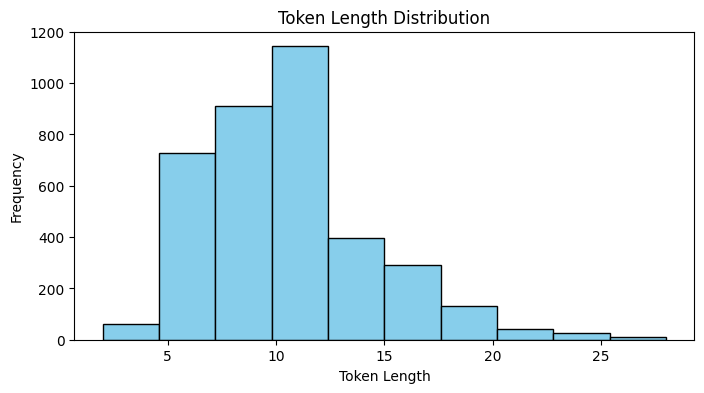

In [ ]:
from transformers import AutoTokenizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tokenizer = AutoTokenizer.from_pretrained('skt/kobert-base-v1', use_fast=False)

df = pd.read_csv('./dialog_data.csv')
cafe_df = df[(df['SPEAKER'] == '고객') & (df['DOMAIN'] == '카페')].copy()

cafe_df['TOKENS'] = cafe_df['SENTENCE'].apply(lambda x: tokenizer.tokenize(x))
cafe_df['TOKEN_LENGTH'] = cafe_df['TOKENS'].apply(len)
for i, (sent, tokens) in cafe_df[['SENTENCE', 'TOKENS']].head(10).iterrows():
    print(f'[문장 {i}] {sent}')
    print(f'  → 토큰: {tokens}')

# 통계 정보 출력
token_lengths = cafe_df['TOKEN_LENGTH']
print(f'총 문장 수: {len(token_lengths)}')
print(f'최대 토큰 길이: {token_lengths.max()}')
print(f'평균 토큰 길이: {token_lengths.mean():.2f}')
print(f'95th 백분위수(상위 10% 컷): {np.percentile(token_lengths, 90)}')
print(f'95th 백분위수(상위 5% 컷): {np.percentile(token_lengths, 95)}')
print(f'99th 백분위수(상위 1% 컷): {np.percentile(token_lengths, 99)}')

# 길이 분포 시각화
plt.figure(figsize=(8,4))
plt.hist(token_lengths, color='skyblue', edgecolor='black')
plt.title('Token Length Distribution')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.show()


In [ ]:
!pip install prettytable
!pip install koeda

import random

import pandas as pd
import torch
import torch.nn as nn
from koeda import EasyDataAugmentation, RandomSwap, RandomDeletion, SynonymReplacement, RandomInsertion
from prettytable import PrettyTable
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from transformers import AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 133.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 46.0 MB/s eta 0:00:00
  Attempting uninstall: tweepy
    Found existing installation: tweepy 4.16.0
    Uninstalling tweepy-4.16.0:
      Successfully uninstalled tweepy-4.16.0
True


In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_accuracy = 0.0
        self.counter = 0
        self.best_model = None

    def __call__(self, accuracy, model):
        if accuracy > self.best_accuracy + self.min_delta:
            self.best_accuracy = accuracy
            self.counter = 0
            self.best_model = model.state_dict()
        else:
            self.counter += 1
        return self.counter >= self.patience

In [ ]:
class IntentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):
        self.sentences = df['SENTENCE'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):  # Dataset 크기 (샘플 개수) 반환
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]

        encoding = self.tokenizer(
            sentence,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
class TransformerEncoderClassifier(nn.Module):
    def __init__(self, vocab_size, pad_id, num_classes, d_model=256, nhead=4, num_layers=3, dim_feedforward=512,
                 max_len=64, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout,
                                                   batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        self.layer_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, attention_mask=None):
        batch_size, seq_len = input_ids.size()
        pos = torch.arange(0, seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)

        x = self.embedding(input_ids) + self.pos_embedding(pos)
        x = self.encoder(x, src_key_padding_mask=(attention_mask == 0))

        x = x[:, -1]
        x = self.layer_norm(x)
        return self.classifier(x)

In [ ]:
def augment_dataframe(df, num_aug=1):
    swap = RandomSwap(morpheme_analyzer='Okt')
    delete = RandomDeletion(morpheme_analyzer='Okt')
    new_data = []
    for _, row in df.iterrows():
        sentence = row['SENTENCE']
        label = row['label']
        new_data.append({'SENTENCE': sentence, 'label': label})
        for _ in range(num_aug):
            new_data.append({'SENTENCE': swap(sentence, 0.0), 'label': label})
            new_data.append({'SENTENCE': delete(sentence, 0.2), 'label': label})
    return pd.DataFrame(new_data)

In [ ]:
def get_data_loader(tokenizer, batch_size=64, max_length=64, num_aug=1):
    df = pd.read_csv('./dialog_data.csv')
    cafe_df = df[(df['SPEAKER'] == '고객') & (df['DOMAIN'] == '카페')].copy()
    cafe_df = cafe_df[['SENTENCE', 'MAIN_GROUPED']].copy()

    # Data 증강
    augmented_df = pd.read_csv('./dialog_data_augmented.csv')
    cafe_df = pd.concat([cafe_df, augmented_df], ignore_index=True)

    # label encoding
    label_encoder = LabelEncoder()
    cafe_df['label'] = label_encoder.fit_transform(cafe_df['MAIN_GROUPED'])
    print(cafe_df)
    cafe_df = cafe_df[['SENTENCE', 'label']].copy()

    cafe_train, cafe_val = train_test_split(cafe_df, test_size=0.2, random_state=42, stratify=cafe_df['label'])
    print(cafe_train)

    cafe_train = augment_dataframe(cafe_train, num_aug)
    print(cafe_train)

    train_dataset = IntentDataset(cafe_train, tokenizer, max_length)
    val_dataset = IntentDataset(cafe_val, tokenizer, max_length)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=1, pin_memory=True)

    return train_loader, val_loader, len(label_encoder.classes_)

In [ ]:
def analyze_model_parameters(model):
    table = PrettyTable(['Layer Name', 'Parameter Count', 'Shape'])
    total_params = 0

    for name, parameter in model.named_parameters():
        if parameter.requires_grad:
            params = parameter.numel()
            table.add_row([name, f'{params:,}', str(list(parameter.shape))])
            total_params += params

    print(table)
    print(f'\n전체 훈련 가능한 파라미터: {total_params:,}')

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

In [ ]:
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * input_ids.size(0)
            predicted = outputs.argmax(dim=1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [ ]:
def train_models(device, batch_size, d_model, nhead, num_layers, dim_feedforward, dropout, label_smoothing,
                 learning_rate, weight_decay, num_aug, epochs, max_length=32):

    early_stopping = EarlyStopping(400, 0)

    # HuggingFace KoBERT tokenizer 사용
    tokenizer = AutoTokenizer.from_pretrained('skt/kobert-base-v1', use_fast=False)

    train_loader, val_loader, num_classes = get_data_loader(tokenizer, batch_size, max_length, num_aug)

    model = TransformerEncoderClassifier(
        vocab_size=len(tokenizer), pad_id=tokenizer.pad_token_id, num_classes=num_classes,
        d_model=d_model, nhead=nhead, num_layers=num_layers,
        dim_feedforward=dim_feedforward, max_len=max_length, dropout=dropout
    ).to(device)

    # Model 정보 출력
    analyze_model_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    writer = SummaryWriter(f'./intent-classification-tf')  # TensorBoard 설정

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = eval_epoch(model, val_loader, criterion, device)

        writer.add_scalars('loss', {'train': train_loss, 'validation': val_loss}, epoch + 1)
        writer.add_scalars('accuracy', {'train': train_acc, 'validation': val_acc}, epoch + 1)
        print(f' Epoch {epoch + 1}: train_loss={train_loss:.4f} acc={train_acc:.4f} '
              f'| val_loss={val_loss:.4f} acc={val_acc:.4f}')

        # Check early stopping condition
        if early_stopping(val_acc, model):
            print('Early stopping triggered.')
            break

    print(f'Training finished. Best Accuracy: {early_stopping.best_accuracy:.4f}')
    writer.close()  # TensorBoard 종료
    torch.save(early_stopping.best_model, './cafe_only.pt')

In [ ]:
experiment_sets = [
    {
        'num_layers': 2,
        'nhead': 4,
        'd_model': 512,
        'dim_feedforward': 512,
        'learning_rate': 1e-5,
        'weight_decay': 1e-4,
        'label_smoothing': 0.3,
        'dropout': 0.4,
        'batch_size': 64,
        'num_aug': 4,
        'epochs': 400
    },
]

for i, params in enumerate(experiment_sets):
    print(f'\n🔹 [Experiment {i + 1}/{len(experiment_sets)}] Params: {params}')
    train_models(device=device, **params)

In [ ]:
# TensorBoard 결과 출력
%load_ext tensorboard
%tensorboard --logdir=./

In [ ]:
from google.colab import runtime
import time

time.sleep(30)
runtime.unassign()